# Data cleaning

In [66]:
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [67]:
df = pd.read_excel(r"../Datasets/uci_concrete_data.xlsx", sheet_name="Sheet1")
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1048.000000,1050.000000,1042.000000,1051.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,281.491308,73.794694,54.148015,181.448016,6.231984,973.076670,773.390569,45.392082,35.907088
std,104.162471,86.110710,63.786094,21.322325,5.944312,77.447901,79.864558,62.353966,16.535634
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,194.680000,0.000000,0.000000,164.900000,0.000000,932.000000,732.050000,14.000000,23.880001
50%,274.000000,22.000000,0.000000,185.000000,6.350000,968.000000,779.320000,28.000000,34.346247
75%,350.000000,142.725000,118.270000,192.000000,10.160000,1029.400000,822.650000,56.000000,46.089490
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [68]:
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                32
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    30
Fly Ash (component 3)(kg in a m^3 mixture)               38
Water  (component 4)(kg in a m^3 mixture)                29
Superplasticizer (component 5)(kg in a m^3 mixture)       0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         0
Age (day)                                                 0
Concrete compressive strength(MPa, megapascals)           0
dtype: int64

### SimpleImputer

In [69]:

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(df)
df_sim_imp = pd.DataFrame(imp.transform(df), columns=df.columns)
#print(df_sim_imp)
#df_sim_imp.isnull().sum()

### Nearest neighbors imputation

In [70]:
imp_near = KNNImputer(n_neighbors=5, weights='distance')
df_near = pd.DataFrame(imp_near.fit_transform(df), columns=df.columns)
#df_near.isnull().sum()
#df_near

### Dropping the rows

In [71]:
df_drop = df.dropna()

#df_drop.isnull().sum()

df_drop.describe()
#df.isnull().sum()
#df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


### Drop duplicates

In [72]:
df_drop.duplicated().sum()
df_drop_dup = df_drop.drop_duplicates()
df_drop_dup.duplicated().sum()

np.int64(0)

### Correlation with respect to compressive strength

In [73]:
df_drop_dup.corr() #Pearson correlation
# we look to the highest positive and the lowest negative ratio wwith respect to compressive strength

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
Cement (component 1)(kg in a m^3 mixture),1.000000,-0.303301,-0.385618,-0.056583,0.061296,-0.086212,-0.245379,0.086349,0.488283
Blast Furnace Slag (component 2)(kg in a m^3 mixture),-0.303301,1.000000,-0.312342,0.130295,0.019902,-0.277558,-0.289676,-0.042759,0.103370
Fly Ash (component 3)(kg in a m^3 mixture),-0.385618,-0.312342,1.000000,-0.283372,0.414055,-0.026485,0.090229,-0.158940,-0.080648
Water (component 4)(kg in a m^3 mixture),-0.056583,0.130295,-0.283372,1.000000,-0.646875,-0.212495,-0.444888,0.279269,-0.269606
Superplasticizer (component 5)(kg in a m^3 mixture),0.061296,0.019902,0.414055,-0.646875,1.000000,-0.242031,0.207794,-0.194094,0.344225
Coarse Aggregate (component 6)(kg in a m^3 mixture),-0.086212,-0.277558,-0.026485,-0.212495,-0.242031,1.000000,-0.162212,-0.005263,-0.144710
Fine Aggregate (component 7)(kg in a m^3 mixture),-0.245379,-0.289676,0.090229,-0.444888,0.207794,-0.162212,1.000000,-0.156572,-0.186457
Age (day),0.086349,-0.042759,-0.158940,0.279269,-0.194094,-0.005263,-0.156572,1.000000,0.337371
"Concrete compressive strength(MPa, megapascals)",0.488283,0.103370,-0.080648,-0.269606,0.344225,-0.144710,-0.186457,0.337371,1.000000


### Visualization

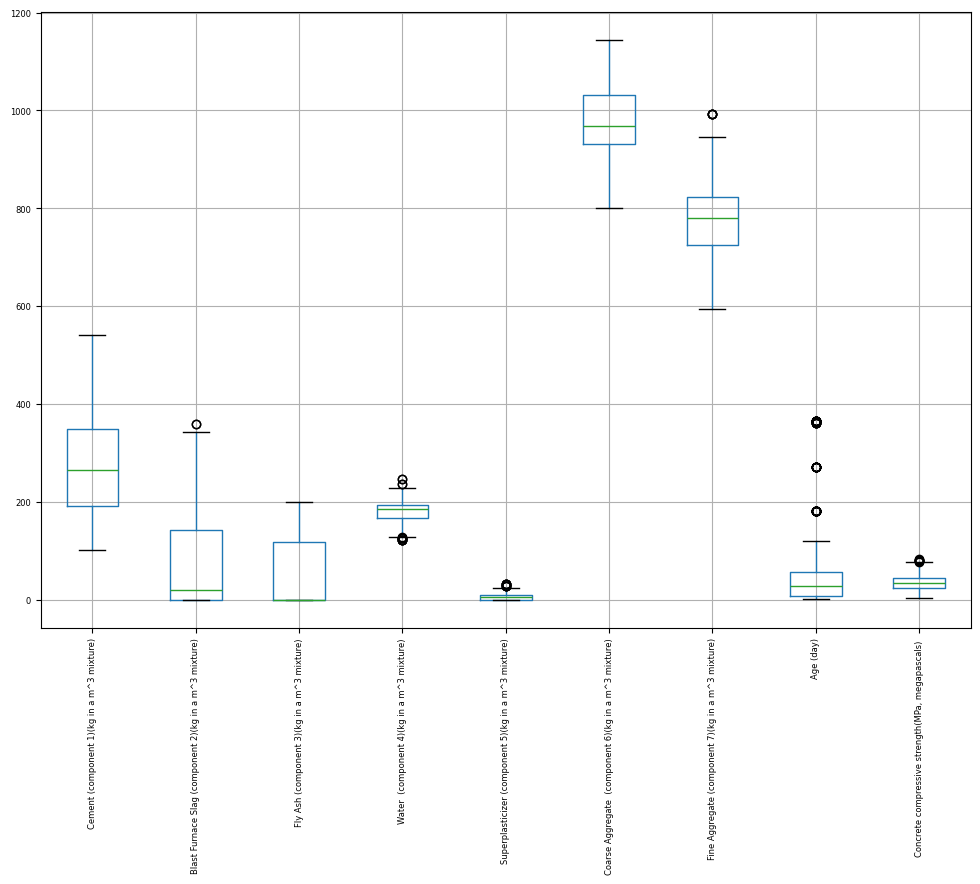

In [74]:
df_drop_dup.boxplot(rot=90, figsize=(12,8), fontsize=6)
plt.show()

### Differentiate input and output data

In [75]:
#dropping duplicates to prevent overfitting but leaving the missing values
df.duplicated().sum()
df_nd = df.drop_duplicates()
df_nd.duplicated().sum()

np.int64(0)

In [76]:
X = df_nd.iloc[:, 0:8]
Y = df_nd.iloc[:, 8]
# X = df_drop_dup.iloc[:, 0:8]
# Y = df_drop_dup.iloc[:, 8]

### Common seed

In [77]:
from sklearn.model_selection import train_test_split, KFold

In [ ]:
seed = 42
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=seed)
kf = KFold(n_splits=4, random_state=seed, shuffle=True)

# Boosting 


## Raw data without cleaning

In [79]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor
from tqdm import tqdm


### Running XGBRegressor, HistGradientBoostingRegressor and AdaBoostRegressor

In [80]:
models = {'XGBRegressor': XGBRegressor(random_state=seed), 
          'HistGradientBoostingRegressor': HistGradientBoostingRegressor(random_state=seed),
          'AdaBoostRegressor':AdaBoostRegressor(random_state=seed)}

# Monotonic constraints applied
#models = {'XGBRegressor': XGBRegressor(monotone_constraints=(1, 0, 0, -1, 0, 0, 0, 1), random_state=seed), 
#          'HistGradientBoostingRegressor': HistGradientBoostingRegressor(monotonic_cst=[1, 0, 0, -1, 0, 0, 0, 1], random_state=seed),
#          'AdaBoostRegressor':AdaBoostRegressor(random_state=seed)}

params = {'XGBRegressor':{'n_estimators': (50, 250, 500, 1000), 'max_depth': (3,5,6,8,10)},
          'HistGradientBoostingRegressor':{'max_iter': (50, 250, 500, 1000), 'max_depth': (3,5,6,8,10)},
          'AdaBoostRegressor':{'n_estimators': (50, 250, 500, 1000)}}


#if you want to apply GridSearch for monotonic constraint uncomment below
#constraint_A = (1, 0, 0, -1, 0, 0, 0, 1) # Cement up, Water down, Age up
#constraint_B = (1, 1, 1, -1, 0, 0, 0, 1) # + Slag and Fly Ash up
#constraint_C = (0, 0, 0, 0, 0, 0, 0, 0)

#params = {'XGBRegressor':{'n_estimators': (50, 250, 500, 1000), 
#                          'max_depth': (3,5,6,8,10),
#                          'monotone_constraints': [constraint_A, constraint_B, constraint_C]},
#          'HistGradientBoostingRegressor':{'max_iter': (50, 250, 500, 1000), 
#                                           'max_depth': (3,5,6,8,10),
#                                           'monotonic_cst': [list(constraint_A), list(constraint_B), list(constraint_C)]},
#          'AdaBoostRegressor':{'n_estimators': (50, 250, 500, 1000)}}

# XGBoost evaluates the Gain for each possible split and selects the best one.
# HistGradientBoostingRegressor splits the data to bins (255 by default)

In [81]:
grid_loop = {}
grid_loop_best_params = {}
Y_pred = {}
mae = {}
rmse = {}
r2 = {}
residual = {}
# Uncomment this line to apply sample weights
#sample_weights = np.where(X_train['Age (day)']>28, 2.0, 1.0) 

for name, model in tqdm(models.items(), desc="Models"):
    if name == 'AdaBoostRegressor':
        continue
    grid_loop[name] = GridSearchCV(estimator=model, 
                                   param_grid=params[name], 
                                   cv=kf,verbose=1)
    # Base model
    grid_loop[name].fit(X_train, Y_train)

    # applying sample weights
    #fit_params = {"sample_weight": sample_weights}
    #grid_loop[name].fit(X_train, Y_train, **fit_params)
    
    grid_loop_best_params[name] = grid_loop[name].best_params_
    Y_pred[name] = grid_loop[name].predict(X_test)
    mae[name] = mean_absolute_error(Y_test, Y_pred[name])
    rmse[name] = root_mean_squared_error(Y_test,Y_pred[name])
    r2[name] = r2_score(Y_test, Y_pred[name])
    residual[name] = np.subtract(Y_test, Y_pred[name])

Models:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting 4 folds for each of 20 candidates, totalling 80 fits


Models:  33%|███▎      | 1/3 [00:34<01:09, 34.54s/it]

Fitting 4 folds for each of 20 candidates, totalling 80 fits


Models: 100%|██████████| 3/3 [01:17<00:00, 25.73s/it]


In [83]:
metrics_dict = {"MAE":mae, "RMSE":rmse, "R":r2, "BestParams": grid_loop_best_params}
metrics = pd.DataFrame(metrics_dict)
params_df=metrics['BestParams'].apply(pd.Series)
metrics = metrics.drop(columns=['BestParams'])
final_metrics = pd.concat([metrics, params_df], axis=1)

final_metrics

,MAE,RMSE,R,max_depth,n_estimators,max_iter
XGBRegressor,2.976851,4.175843,0.939340,3.0,250.0,NaN
HistGradientBoostingRegressor,2.757356,4.149147,0.940113,5.0,NaN,1000.0


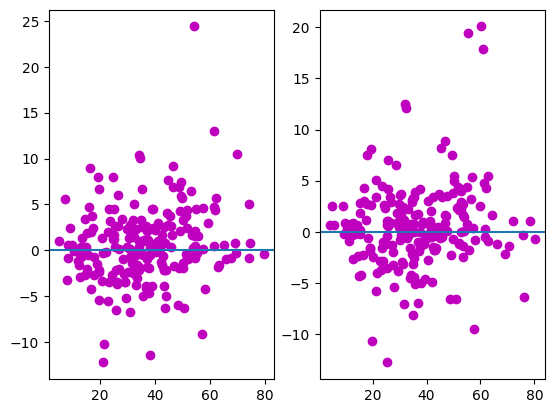

In [84]:
fig, axes = plt.subplots(1, 2)
axes[0].scatter(Y_pred['XGBRegressor'], residual['XGBRegressor'], c="m")
axes[1].scatter(Y_pred['HistGradientBoostingRegressor'], residual['HistGradientBoostingRegressor'], c="m")
axes[0].axhline(0)
axes[1].axhline(0)
plt.show()

## Boosting models after data cleaning

In [85]:
X_c = df_drop_dup.iloc[:, 0:8]
Y_c = df_drop_dup.iloc[:, 8]

In [86]:
X_train_c, X_test_c, Y_train_c, Y_test_c = train_test_split(X_c, Y_c, test_size=0.2, random_state=seed)
kf_c = KFold(n_splits=4, random_state=seed, shuffle=True)

In [87]:
grid_loop_c = {}
grid_loop_best_params_c = {}
Y_pred_c = {}
mae_c = {}
rmse_c = {}
r2_c = {}
residual_c = {}

# Uncomment the line below to apply sample weights
#sample_weights_c = np.where(X_train_c['Age (day)']>28, 2.0, 1.0)

for name, model in models.items():
    grid_loop_c[name] = GridSearchCV(estimator=model, 
                                     param_grid=params[name], 
                                     cv=kf_c)
    #grid_loop_c[name].fit(X_train_c, Y_train_c)

    # applying sample weights 
    #fit_params_c = {"sample_weight": sample_weights_c}
    #grid_loop_c[name].fit(X_train_c, Y_train_c, **fit_params_c)
    
    
    grid_loop_best_params_c[name] = grid_loop_c[name].best_params_
    Y_pred_c[name] = grid_loop_c[name].predict(X_test_c)
    mae_c[name] = mean_absolute_error(Y_test_c, Y_pred_c[name])
    rmse_c[name] = root_mean_squared_error(Y_test_c,Y_pred_c[name])
    r2_c[name] = r2_score(Y_test_c, Y_pred_c[name])
    residual_c[name] = np.subtract(Y_test_c, Y_pred_c[name])

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [ ]:
metrics_dict_c = {"MAE_CD":mae_c, "RMSE_CD":rmse_c, "R_CD":r2_c, "BestParams_CD": grid_loop_best_params_c}
metrics_c = pd.DataFrame(metrics_dict_c)
params_df_c=metrics_c['BestParams_CD'].apply(pd.Series)
metrics_c = metrics_c.drop(columns=['BestParams_CD'])
final_metrics_c = pd.concat([metrics_c, params_df_c], axis=1)

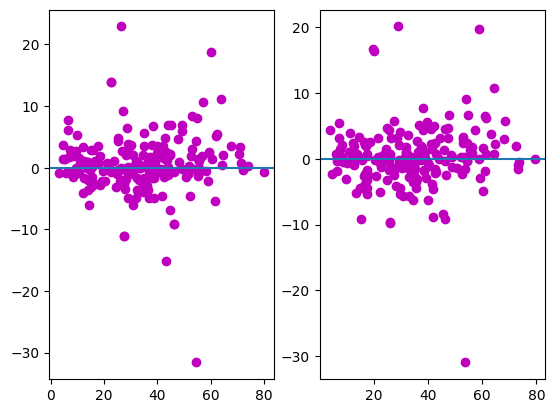

In [ ]:
fig, axes = plt.subplots(1, 2)
axes[0].scatter(Y_pred_c['XGBRegressor'], residual_c['XGBRegressor'], c="m")
axes[1].scatter(Y_pred_c['HistGradientBoostingRegressor'], residual_c['HistGradientBoostingRegressor'], c="m")
axes[0].axhline(0)
axes[1].axhline(0)
plt.show()

In [ ]:
final_metrics

,MAE,RMSE,R,max_depth,monotone_constraints,n_estimators,max_iter,monotonic_cst
XGBRegressor,3.217409,4.714844,0.914522,10,"(1, 0, 0, -1, 0, 0, 0, 1)",50.0,NaN,NaN
HistGradientBoostingRegressor,3.291138,4.973298,0.904893,3,NaN,NaN,1000.0,"[0, 0, 0, 0, 0, 0, 0, 0]"


In [ ]:
final_metrics_c

,MAE_CD,RMSE_CD,R_CD,max_depth,monotone_constraints,n_estimators,max_iter,monotonic_cst
XGBRegressor,3.029133,4.906914,0.922896,3.0,"(0, 0, 0, 0, 0, 0, 0, 0)",1000.0,NaN,NaN
HistGradientBoostingRegressor,2.954146,4.750469,0.927734,5.0,NaN,NaN,1000.0,"[0, 0, 0, 0, 0, 0, 0, 0]"
AdaBoostRegressor,6.394682,7.694566,0.810405,NaN,NaN,500.0,NaN,NaN


In [ ]:
combined_metrics = pd.concat([final_metrics, final_metrics_c], axis=1)

combined_metrics.to_excel("boosting_family_results.xlsx", index=True)
